In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values after cleaning:")
print(df.isnull().sum().sum())

Remaining missing values after cleaning:
0


In [9]:
# Feature engineering: derive Profit Margin (%) for economic comparison
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

# Sanity check on final cleaned data
df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha', 'Profit_Margin_pct']].describe()

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha,Profit_Margin_pct
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,600.714313,26.504525,5.241955,-45.492178
std,288.427366,6.696998,13.311661,158.085472
min,80.000000,8.000000,0.300000,-1461.851219
25%,370.425000,21.700000,1.050000,-60.192762
50%,581.000000,26.400000,1.730000,1.146236
75%,836.125000,31.200000,2.830000,32.885876
max,1395.200000,47.000000,101.440000,85.921220


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


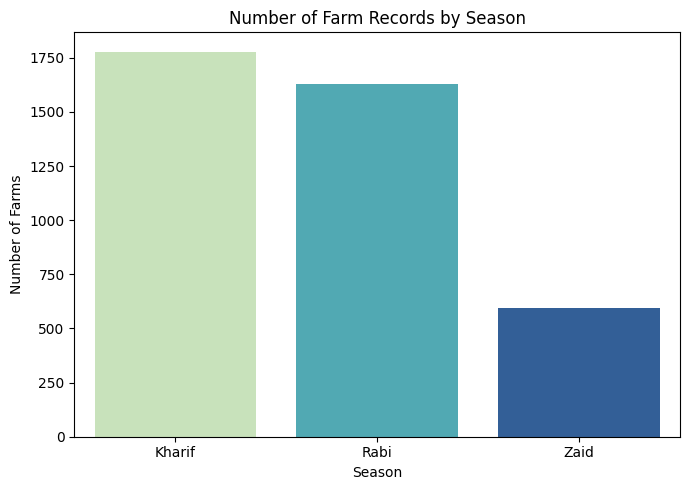

In [10]:
season_counts = df['Season'].value_counts()
print(season_counts)

plt.figure(figsize=(7,5))
sns.barplot(x=season_counts.index, y=season_counts.values, hue=season_counts.index,
            palette='YlGnBu', legend=False)
plt.title('Number of Farm Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.tight_layout()
plt.show()

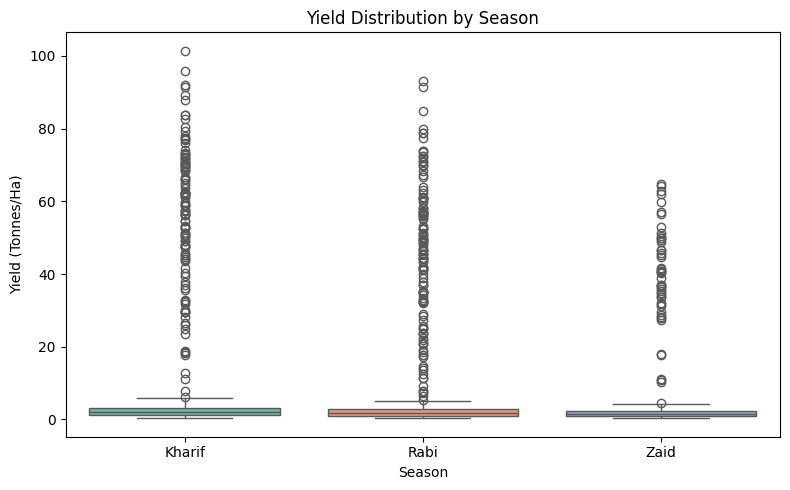

,mean,median,std
Season,,,
Kharif,5.63,1.95,14.39
Rabi,5.04,1.66,12.75
Zaid,4.64,1.45,11.27


In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', hue='Season', data=df, palette='Set2', legend=False)
plt.title('Yield Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

df.groupby('Season')['Yield_Tonnes_Ha'].agg(['mean','median','std']).round(2)

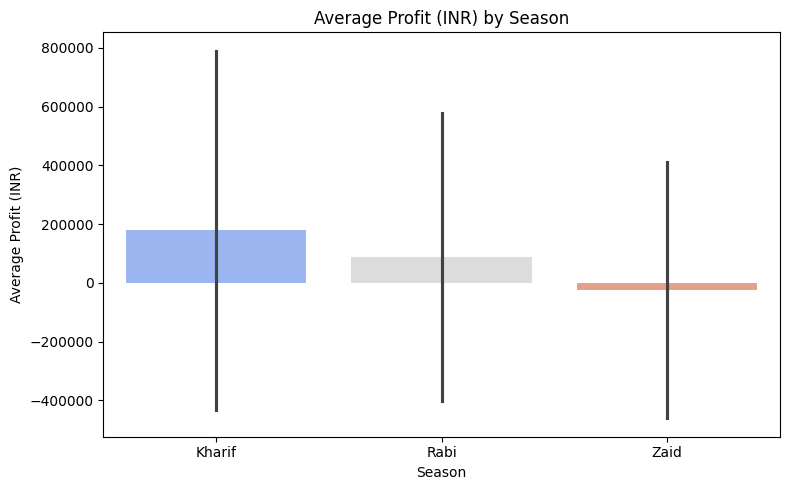

,Profit_INR,Profit_Margin_pct
Season,,
Kharif,178914.65,-38.64
Rabi,87689.47,-44.27
Zaid,-24804.82,-69.35


In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='Season', y='Profit_INR', hue='Season', data=df, estimator=np.mean,
            palette='coolwarm', legend=False, errorbar='sd')
plt.title('Average Profit (INR) by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.tight_layout()
plt.show()

df.groupby('Season')[['Profit_INR','Profit_Margin_pct']].mean().round(2)

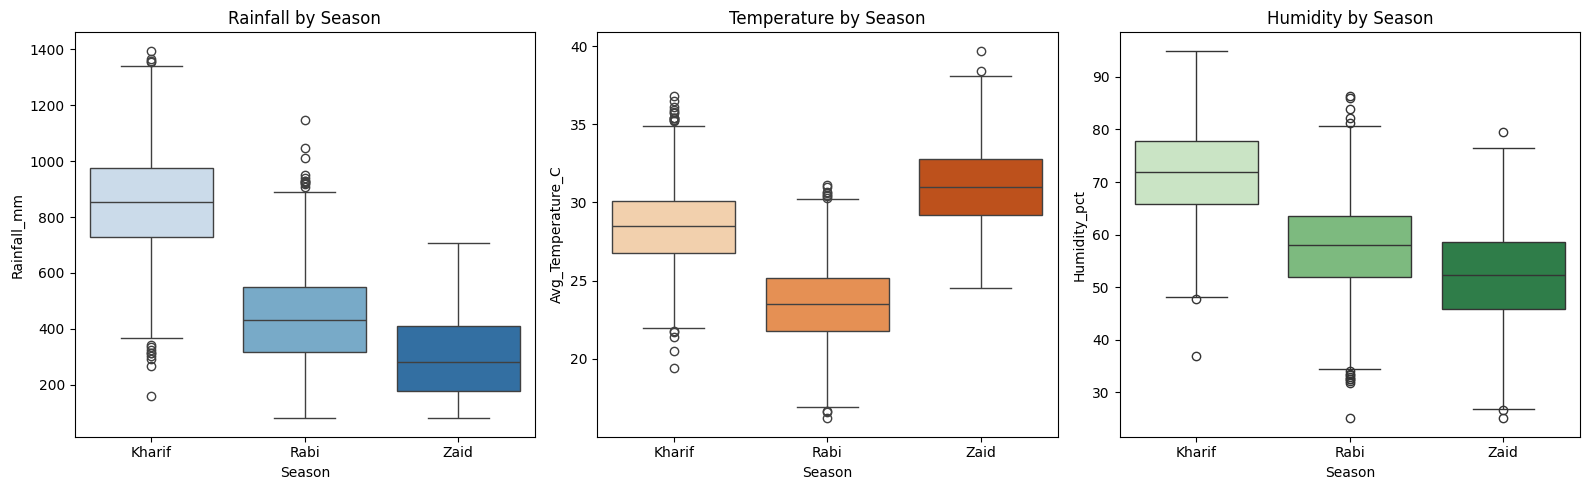

,Rainfall_mm,Avg_Temperature_C,Humidity_pct
Season,,,
Kharif,852.11,28.45,71.81
Rabi,435.94,23.49,57.89
Zaid,299.12,31.04,52.01


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.boxplot(x='Season', y='Rainfall_mm', hue='Season', data=df, ax=axes[0], palette='Blues', legend=False)
axes[0].set_title('Rainfall by Season')

sns.boxplot(x='Season', y='Avg_Temperature_C', hue='Season', data=df, ax=axes[1], palette='Oranges', legend=False)
axes[1].set_title('Temperature by Season')

sns.boxplot(x='Season', y='Humidity_pct', hue='Season', data=df, ax=axes[2], palette='Greens', legend=False)
axes[2].set_title('Humidity by Season')

plt.tight_layout()
plt.show()

df.groupby('Season')[['Rainfall_mm','Avg_Temperature_C','Humidity_pct']].mean().round(2)


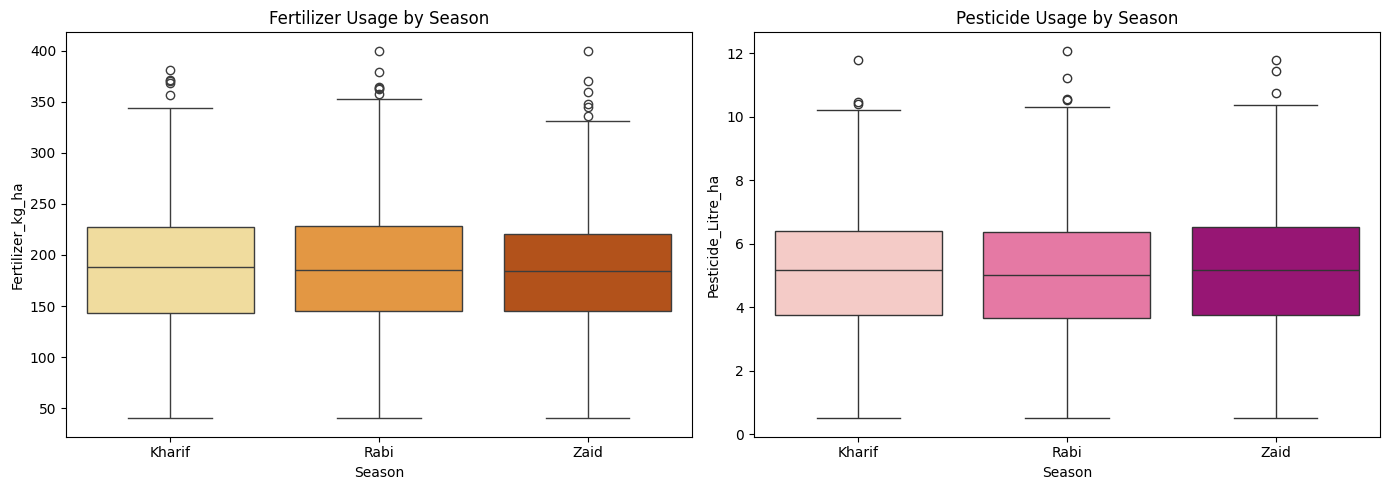

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x='Season', y='Fertilizer_kg_ha', hue='Season', data=df, ax=axes[0], palette='YlOrBr', legend=False)
axes[0].set_title('Fertilizer Usage by Season')

sns.boxplot(x='Season', y='Pesticide_Litre_ha', hue='Season', data=df, ax=axes[1], palette='RdPu', legend=False)
axes[1].set_title('Pesticide Usage by Season')

plt.tight_layout()
plt.show()

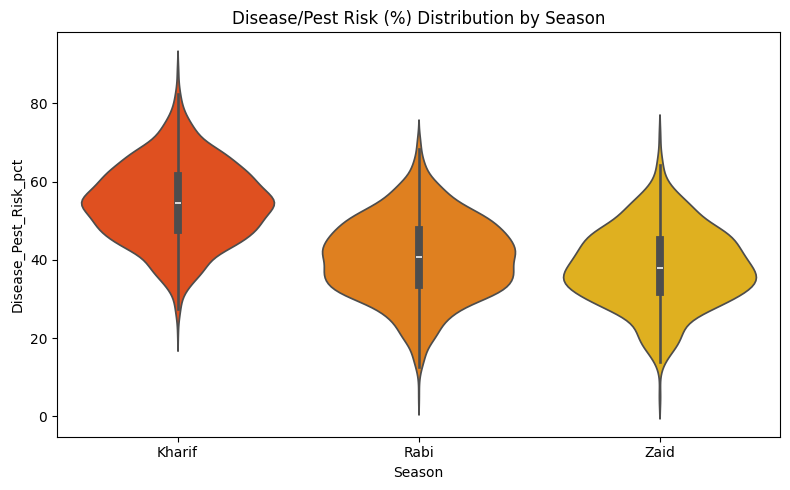

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


In [15]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Season', y='Disease_Pest_Risk_pct', hue='Season', data=df, palette='autumn', legend=False)
plt.title('Disease/Pest Risk (%) Distribution by Season')
plt.tight_layout()
plt.show()

df.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2)


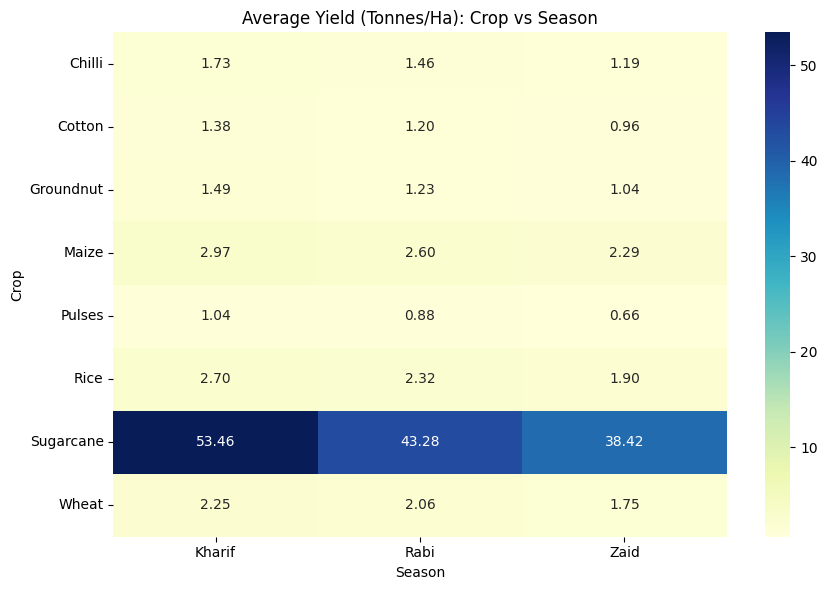

In [16]:
pivot_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean')

plt.figure(figsize=(9,6))
sns.heatmap(pivot_yield.round(2), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Average Yield (Tonnes/Ha): Crop vs Season')
plt.tight_layout()
plt.show()

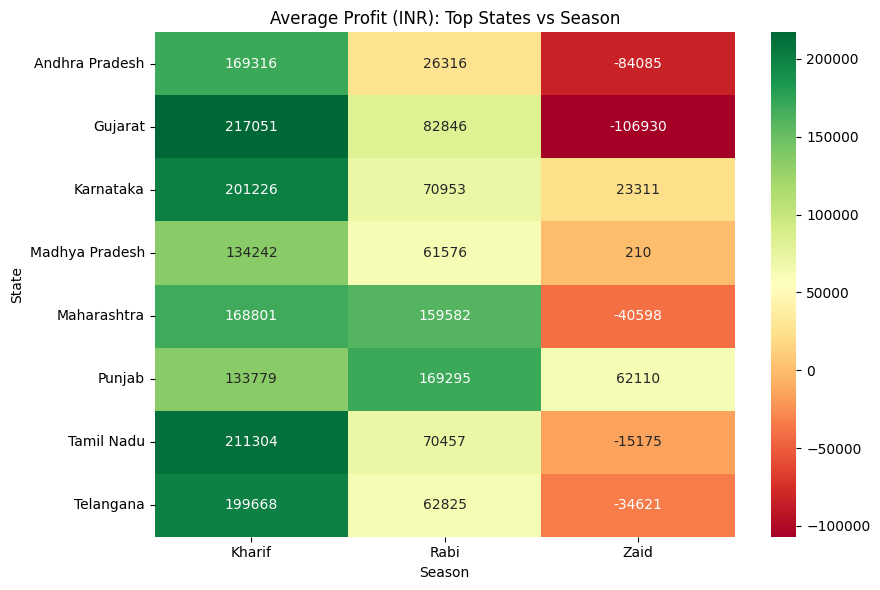

In [17]:
top_states = df['State'].value_counts().head(8).index
pivot_profit = df[df['State'].isin(top_states)].pivot_table(
    values='Profit_INR', index='State', columns='Season', aggfunc='mean')

plt.figure(figsize=(9,6))
sns.heatmap(pivot_profit.round(0), annot=True, cmap='RdYlGn', fmt='.0f')
plt.title('Average Profit (INR): Top States vs Season')
plt.tight_layout()
plt.show()

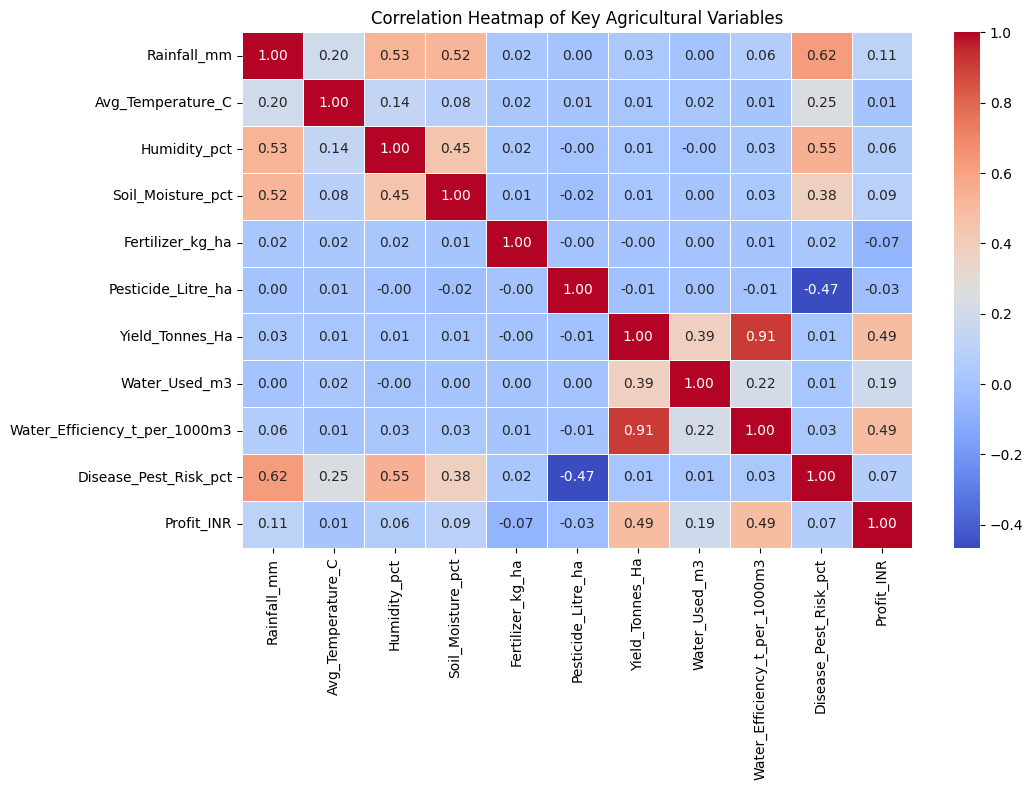

In [18]:
numeric_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
                 'Fertilizer_kg_ha','Pesticide_Litre_ha','Yield_Tonnes_Ha',
                 'Water_Used_m3','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Profit_INR']

plt.figure(figsize=(11,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Agricultural Variables')
plt.tight_layout()
plt.show()

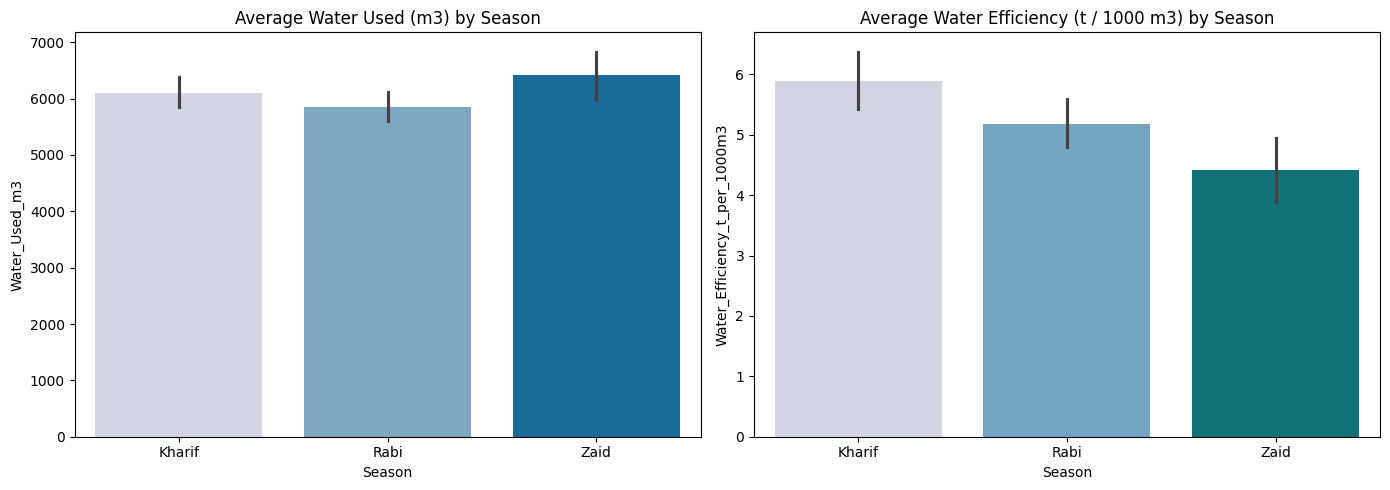

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(x='Season', y='Water_Used_m3', hue='Season', data=df, ax=axes[0],
            estimator=np.mean, palette='PuBu', legend=False)
axes[0].set_title('Average Water Used (m3) by Season')

sns.barplot(x='Season', y='Water_Efficiency_t_per_1000m3', hue='Season', data=df, ax=axes[1],
            estimator=np.mean, palette='PuBuGn', legend=False)
axes[1].set_title('Average Water Efficiency (t / 1000 m3) by Season')

plt.tight_layout()
plt.show()

df.groupby('Season')[['Water_Used_m3','Water_Efficiency_t_per_1000m3']].mean().round(2)

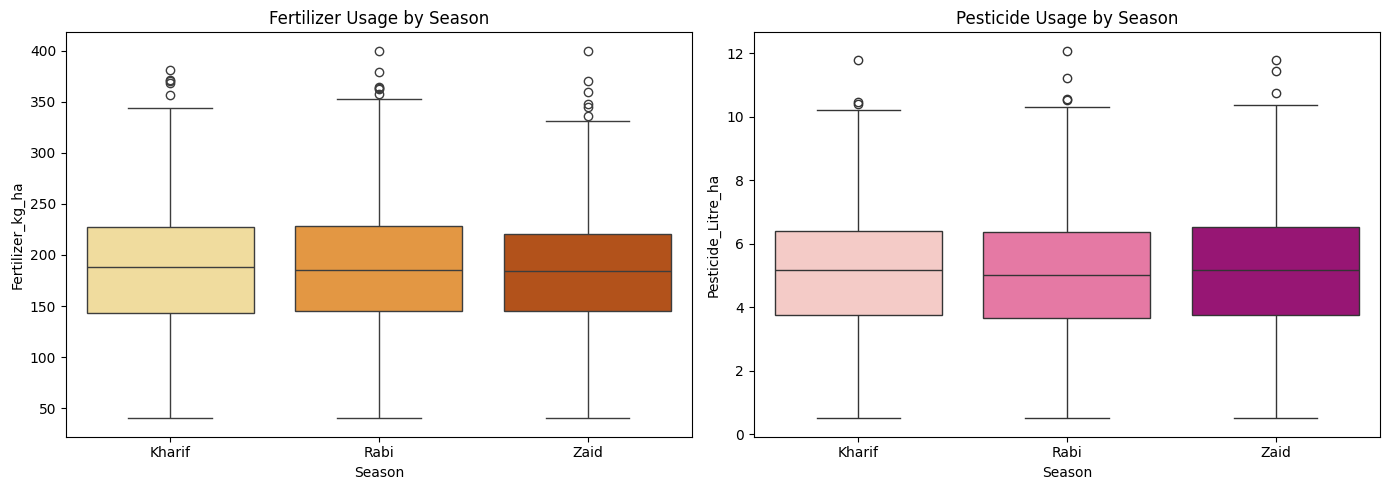

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x='Season', y='Fertilizer_kg_ha', hue='Season', data=df, ax=axes[0], palette='YlOrBr', legend=False)
axes[0].set_title('Fertilizer Usage by Season')

sns.boxplot(x='Season', y='Pesticide_Litre_ha', hue='Season', data=df, ax=axes[1], palette='RdPu', legend=False)
axes[1].set_title('Pesticide Usage by Season')

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

kharif_yield = df[df['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi_yield   = df[df['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid_yield   = df[df['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)
print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("\nResult: Statistically significant difference in Yield across seasons (p < 0.05).")
else:
    print("\nResult: No statistically significant difference in Yield across seasons (p >= 0.05).")

ANOVA F-statistic: 1.554
P-value: 0.21156

Result: No statistically significant difference in Yield across seasons (p >= 0.05).


In [22]:
profit_kharif = df[df['Season']=='Kharif']['Profit_INR']
profit_rabi   = df[df['Season']=='Rabi']['Profit_INR']
profit_zaid   = df[df['Season']=='Zaid']['Profit_INR']

f_stat2, p_value2 = stats.f_oneway(profit_kharif, profit_rabi, profit_zaid)
print(f"ANOVA F-statistic (Profit): {f_stat2:.3f}")
print(f"P-value: {p_value2:.5f}")

if p_value2 < 0.05:
    print("\nResult: Statistically significant difference in Profit across seasons (p < 0.05).")
else:
    print("\nResult: No statistically significant difference in Profit across seasons (p >= 0.05).")

ANOVA F-statistic (Profit): 34.292
P-value: 0.00000

Result: Statistically significant difference in Profit across seasons (p < 0.05).


In [23]:
summary = df.groupby('Season').agg(
    Avg_Rainfall_mm=('Rainfall_mm','mean'),
    Avg_Temperature_C=('Avg_Temperature_C','mean'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha','mean'),
    Avg_Fertilizer_kg_ha=('Fertilizer_kg_ha','mean'),
    Avg_Water_Used_m3=('Water_Used_m3','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct','mean'),
    Avg_Profit_INR=('Profit_INR','mean'),
    Avg_Profit_Margin_pct=('Profit_Margin_pct','mean')
).round(2)

summary

,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_t_ha,Avg_Fertilizer_kg_ha,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Avg_Profit_INR,Avg_Profit_Margin_pct
Season,,,,,,,,,
Kharif,852.11,28.45,5.63,187.08,6102.20,5.89,54.47,178914.65,-38.64
Rabi,435.94,23.49,5.04,185.41,5846.99,5.19,40.48,87689.47,-44.27
Zaid,299.12,31.04,4.64,184.64,6419.89,4.41,38.22,-24804.82,-69.35


Yield_Tonnes_Ha: 302 outliers found (out of 4000 rows)
Profit_INR: 404 outliers found (out of 4000 rows)


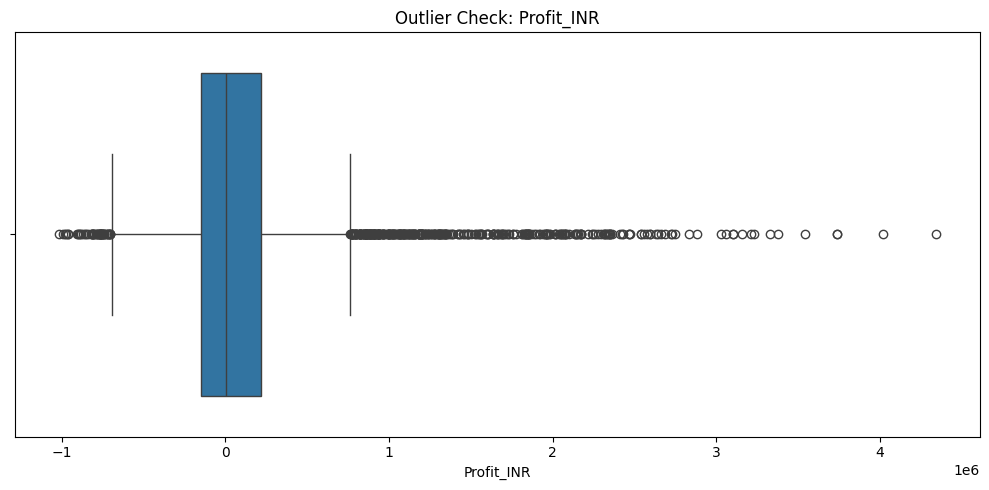

In [24]:
## Outlier Investigation


for col in ['Yield_Tonnes_Ha', 'Profit_INR']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers found (out of {len(df)} rows)")

plt.figure(figsize=(10,5))
sns.boxplot(x=df['Profit_INR'])
plt.title('Outlier Check: Profit_INR')
plt.tight_layout()
plt.show()

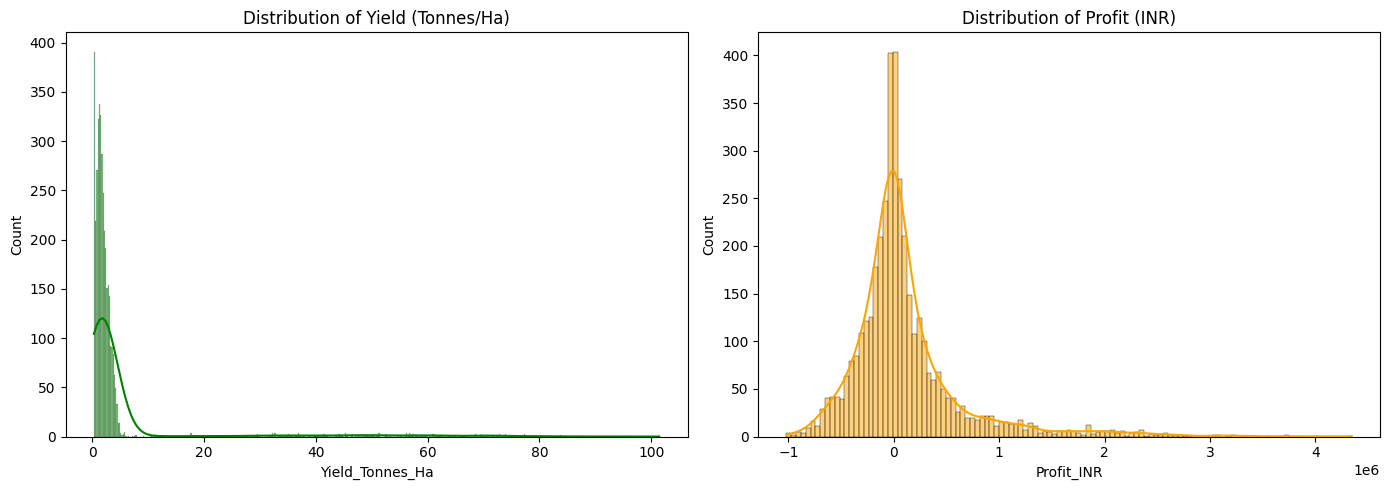

In [25]:
## Univariate Analysis

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['Yield_Tonnes_Ha'], kde=True, ax=axes[0], color='green')
axes[0].set_title('Distribution of Yield (Tonnes/Ha)')

sns.histplot(df['Profit_INR'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Profit (INR)')

plt.tight_layout()
plt.show()

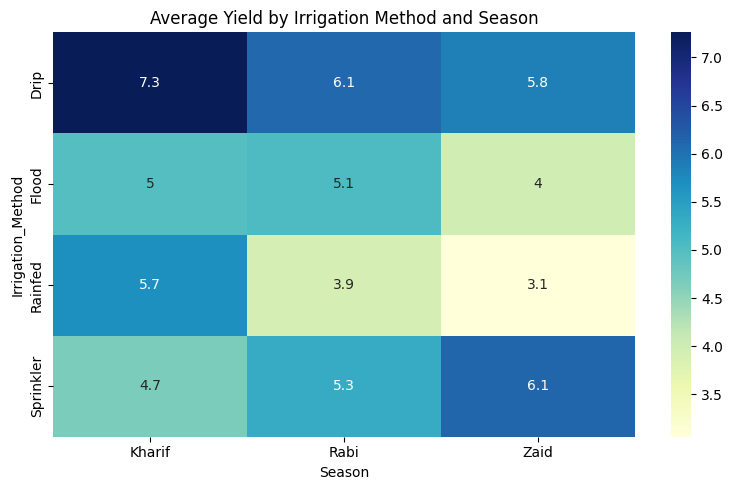

In [29]:
#Student-Designed Analyses

irrigation_season = df.pivot_table(values='Yield_Tonnes_Ha', index='Irrigation_Method', columns='Season', aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(irrigation_season.round(2), annot=True, cmap='YlGnBu')
plt.title('Average Yield by Irrigation Method and Season')
plt.tight_layout()
plt.show()

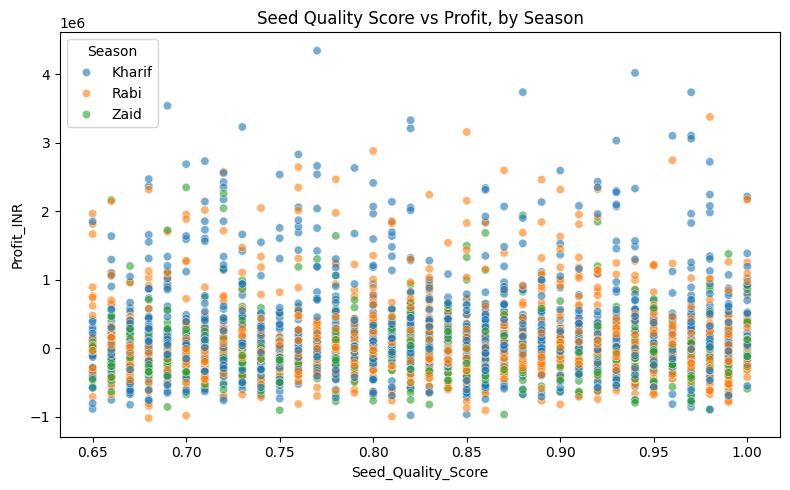

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Seed_Quality_Score', y='Profit_INR', hue='Season', data=df, alpha=0.6)
plt.title('Seed Quality Score vs Profit, by Season')
plt.tight_layout()
plt.show()

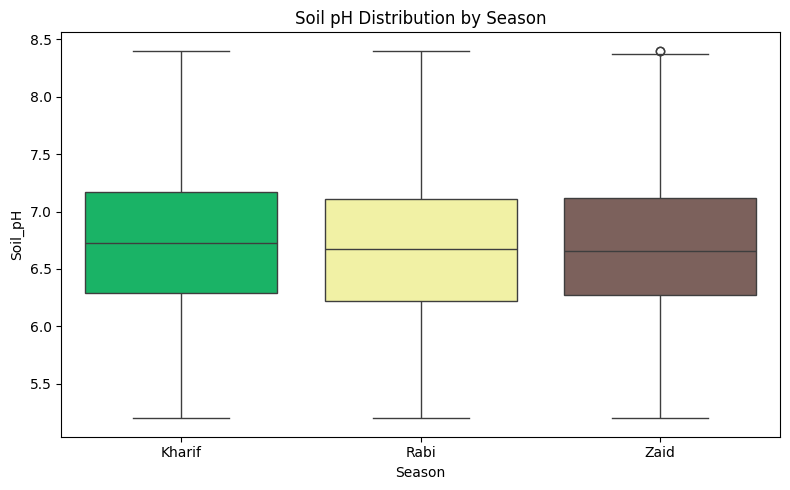

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='Soil_pH', hue='Season', data=df, palette='terrain', legend=False)
plt.title('Soil pH Distribution by Season')
plt.tight_layout()
plt.show()

## Limitations

- The dataset represents a single time snapshot rather than multiple years, so long-term climate trends cannot be captured.
- Cost, revenue, and profit figures are static values and may not reflect real-time market price fluctuations.
- The dataset does not include actual weather forecast data, only historical rainfall/temperature/humidity averages.
- Soil and environmental readings are point estimates and may not capture variability within a single farm.
- Correlational relationships identified do not imply causation.

## Key Insights (Summary)

1. Profit differs significantly across seasons (ANOVA p < 0.00001), while yield differences across seasons are not statistically significant (p = 0.212).
2. Kharif season shows the highest rainfall, but this does not directly translate into the highest yield.
3. Water efficiency (tonnes produced per 1000 m³) varies by season, showing that irrigation input does not scale uniformly with output.
4. Seasonal yield patterns differ by crop — some crops peak in Rabi, others in Kharif, showing no single "best" season across all crops.
5. Disease/pest risk shows a noticeable seasonal pattern, likely tied to humidity and temperature differences.
6. Fertilizer and pesticide usage vary by season, suggesting some existing adaptation in farming practices.
7. State-wise seasonal profit is inconsistent — a season profitable in one state is not necessarily profitable in another, pointing to regional factors beyond season alone.
8. Outlier analysis shows a small number of unusually high/low profit and yield records, likely representing extreme weather years or reporting variation rather than data errors.